# La Transformada de Fourier y el espectrograma

Joseph Fourier fue un matemático francés que alrededor de 1807 propuso que cualquier función periódica, es decir, cualquier señal que se repite en el tiempo, puede ser representada como una suma de funciones sinusoidales de diferentes frecuencias, amplitudes y fases. Desarrolló lo que conocemos como la transformada de Fourier, aportando al mundo una herramienta tanto fascinante como fundamental para el análisis y procesamiento de señales. Hoy en día es la base del análisis espectral, que permite de manera precisa descomponer una señal en sus componentes en función de la frecuencia a partir de los coeficientes de magnitud y fase, los cuales nos brindan información sobre la intensidad y el desplazamiento de cada componente sinusoidal, respectivamente. De esta manera y gracias a los avances tecnológicos, nos es posible manipular, analizar y procesar las señales de manera digital, lo que ha permitido el desarrollo de una amplia gama de aplicaciones en campos como la ingeniería, las telecomunicaciones, la medicina, entre otros.

En este notebook nos limitaremos a procesar los dos archivos de audio usados anteriormente, con el objetivo de visualizar y analizar estas señales de audio digital a través de la transformada de Fourier y el espectrograma, haciendo uso de la biblioteca de Python llamada Librosa, la cual es una biblioteca de análisis de audio muy popular en la comunidad de procesamiento de señales y aprendizaje automático. Librosa proporciona una amplia gama de funciones para cargar, analizar y procesar señales de audio.

Si desea profundizar sobre la transformada de Fourier, visite como primera parada el siguiente contenido audiovisual, proveniente del canal de YouTube de 3Blue1Brown, el cual explica de manera visual y clara los conceptos fundamentales:

[![Video de 3Blue1Brown sobre la transformada de Fourier](https://img.youtube.com/vi/spUNpyF58BY/0.jpg)](https://www.youtube.com/watch?v=spUNpyF58BY)

En cuanto a material de lectura, el libro Fundamentals of Music Processing de Meinard Müller es un libro de muy completo que incluye ejemplos prácticos en notebooks de Python en los que se abarcan todos los fundamentos del procesamiento de señales de audio, incluyend obviamente, la transformada de Fourier. El libro está disponible en línea:  [Fundamentals of Music Processing](https://link.springer.com/book/10.1007/978-3-030-69808-9)

In [24]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import os
import IPython.display as ipd


In [43]:
## Load audio files
BASE_DIR = "./Actor_01"
audio_file_1 = os.path.join(BASE_DIR, "01.wav")
audio_file_2 = os.path.join(BASE_DIR, "05.wav")

In [44]:
ipd.Audio(audio_file_1)


In [45]:
ipd.Audio(audio_file_2)

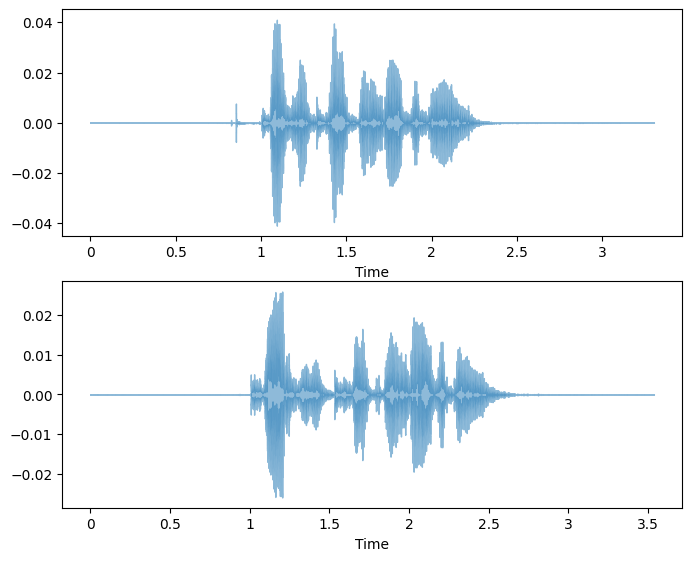

In [46]:
# Cargamos los archivos de audio

plt.figure(figsize=(8, 10))

ax = plt.subplot(3, 1, 1)
signal, sr = librosa.load(audio_file_1)
signal_2, sr = librosa.load(audio_file_2)

# plot forma de onda

librosa.display.waveshow(signal, sr=sr, alpha=0.5)

plt.subplot(3, 1, 2)
librosa.display.waveshow(signal_2, sr=sr, alpha=0.5)
plt.show()

In [47]:
# aplicamos la transformada de Fourier a cada señal

ft = sp.fft.fft(signal)
ft_2 = sp.fft.fft(signal_2)

magnitude_1 = np.absolute(ft)
frequency_1 = np.linspace(0, sr, len(magnitude_1)) 

magnitude_2 = np.absolute(ft_2)
frequency_2 = np.linspace(0, sr, len(magnitude_2)) 


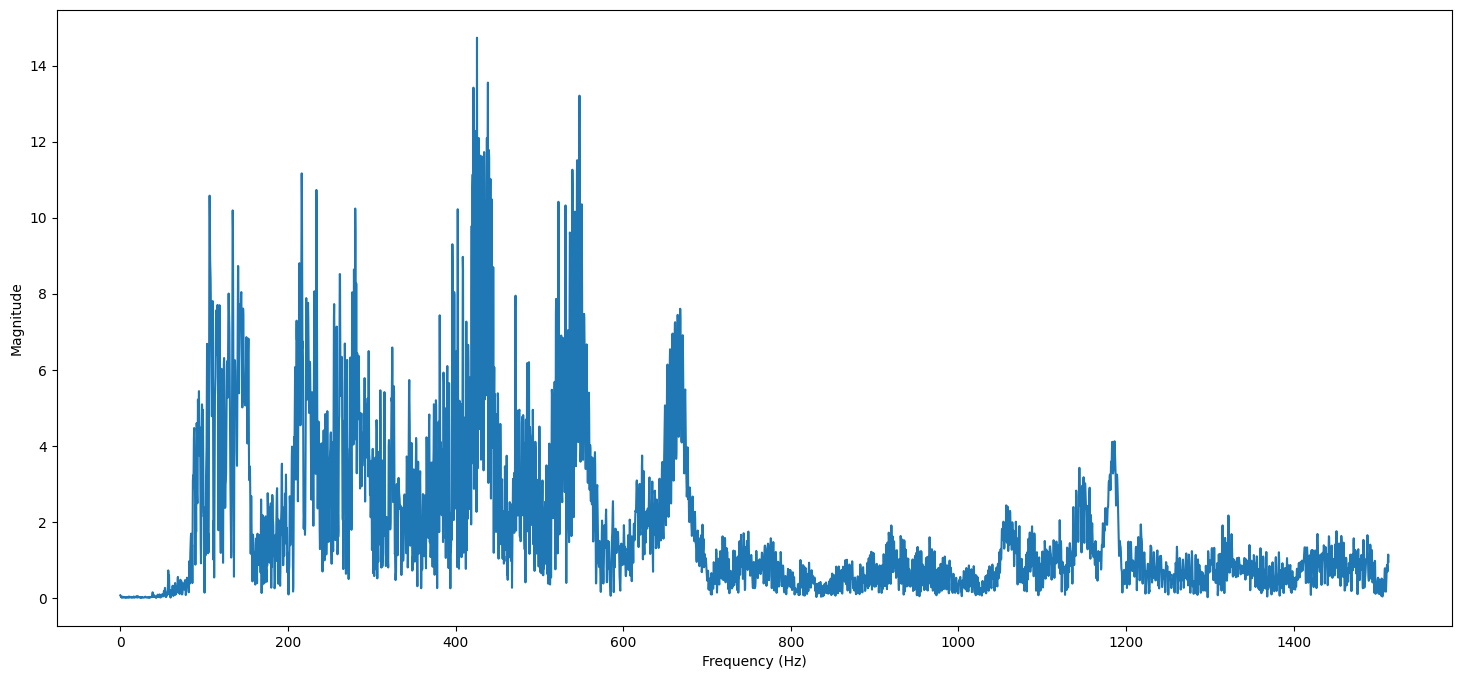

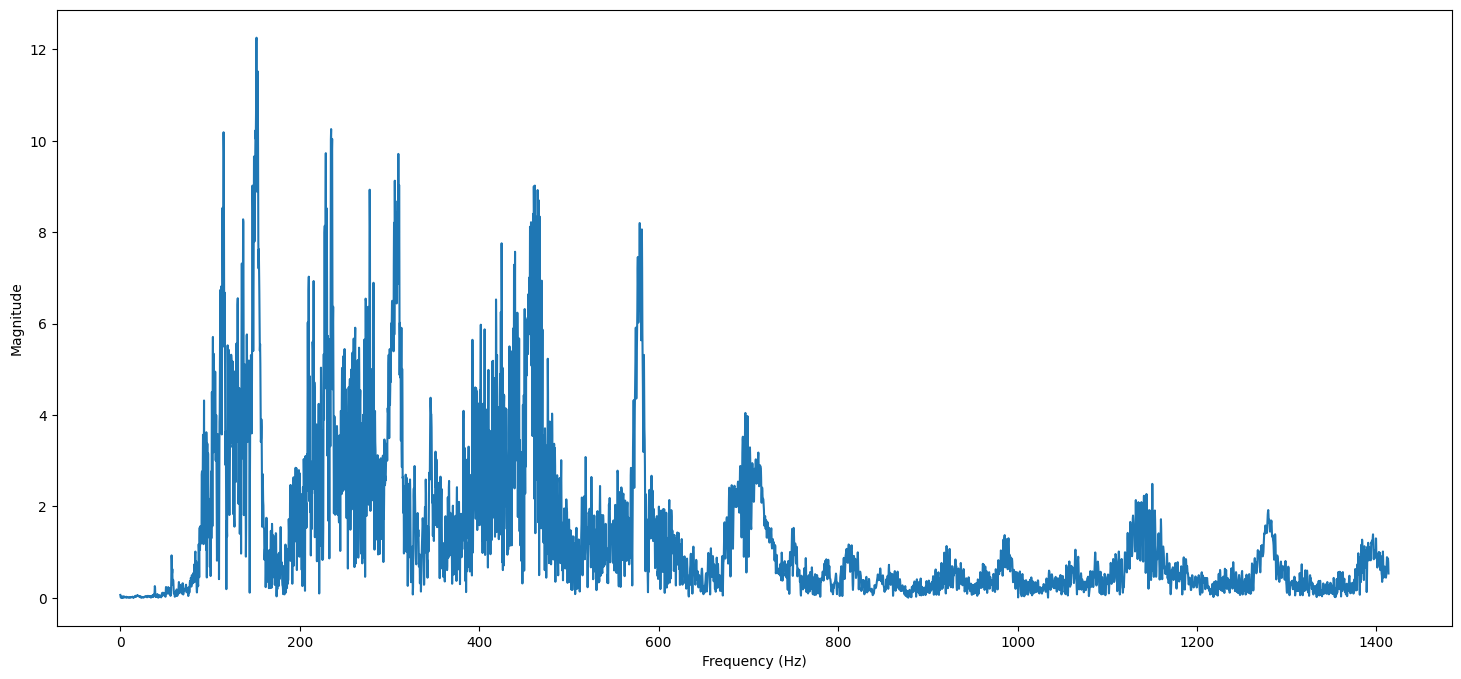

In [48]:
# plot spectrum
plt.figure(figsize=(18, 8))
plt.plot(frequency_1[:5000], magnitude_1[:5000]) # magnitude spectrum
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

# plot spectrum
plt.figure(figsize=(18, 8))
plt.plot(frequency_2[:5000], magnitude_2[:5000]) # magnitude spectrum
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.show()

Como se observa en las secciones anteriores, tras aplicar la transformada de Fourier a los clips de audio para obtener una visión preliminar de su comportamiento en frecuencia, es notable que estos fragmentos contienen información que, a simple vista, resulta casi inútil de analizar. Con el fin de extraer información suficiente para obtener conclusiones que permitan diferenciar y/o clasificar estos archivos, es necesario hacer uso de algunas herramientas más, con las que podremos obtener una abstracción más simple, contundente y humanizada, que además será la base para el proceso de entrenamiento de nuestro modelo de Machine Learning.

### STFT(Short-Time Fourier Transform)

Es una técnica que nos permite analizar la evolución temporal de las frecuencias presentes en una señal de audio. A diferencia de la transformada de Fourier tradicional, que proporciona información sobre las frecuencias presentes en una señal pero no sobre cuándo ocurren, la STFT divide la señal en segmentos más pequeños (ventanas) y aplica la transformada de Fourier a cada segmento. Esto nos permite obtener un espectrograma, que es una representación visual de cómo las frecuencias cambian a lo largo del tiempo. 

### Espectrograma de Mel y la escala logarítmica:

Debido a que el ser humano posee una excelente capacidad para percibir intensidades sonoras en un rango muy amplio, es común utilizar una escala logarítmica para representar la magnitud de las frecuencias en un espectrograma. Por ejemplo, si hablamos en términos de vatios (W), el rango de audición humana va desde aproximadamente **$10^{-12}$ W** (umbral de audición) hasta **1 W** (umbral de dolor). Esto haría que representar todo el rango en una gráfica fuera muy poco práctico, ya que la diferencia de magnitudes en algunos casos sería gigantesca. En cambio, si hablamos en términos de decibelios (dB), el rango de audición humana se sitúa entre los **0 dB y los 120 dB**. Esta escala logarítmica es mucho más adecuada para los espectrogramas, ya que permite visualizar con mayor precisión las variaciones en la intensidad sonora percibida.

El espectrograma de Mel es una representación visual de la energía de las frecuencias presentes en una señal de audio a lo largo del tiempo, utilizando la escala de Mel para representar las frecuencias. La escala de Mel es una escala perceptual que se basa en cómo **los humanos perciben** al ser una no lineal dado el hecho de que el oído humano es muy sensible a cambios en frecuencias bajas, pero le cuesta distinguir cambios en frecuencias altas.

Ej. Para nosotros, la diferencia entre 500 Hz y 1000 Hz es enorme, pero entre 15,000 Hz y 15,500 Hz es casi imperceptible.

Es por eso que los en Filtros de Mel se utilizan un banco de filtros triangulares que se vuelven más anchos a medida que aumenta la frecuencia.

Esto hace que el espectrograma de Mel sea especialmente útil para tareas relacionadas con el procesamiento de audio, como el reconocimiento de voz y la clasificación de emociones, ya que se alinea mejor con la forma en que los humanos perciben el sonido.